In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load dataset
data_path = "DUMP_27 Feb - Raw Data.csv"
df = pd.read_csv(data_path)

# Display dataset info
df.info()

def preprocess_data(df):
    # Standardizing column names
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
    
    # Convert date columns to datetime format
    date_cols = ['instance_date', 'last_lead_activity_date', 'last_activity_date']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # Standardizing text columns
    text_cols = ['lead_origin', 'lead_stage', 'lead_status', 'country', 'state', 'course', 'enrolment_status']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip()
    
    return df

df = preprocess_data(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149979 entries, 0 to 149978
Data columns (total 23 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Name                     149978 non-null  object
 1   Email                    149979 non-null  object
 2   Mobile                   149979 non-null  object
 3   Lead Origin              149979 non-null  object
 4   Country                  149979 non-null  object
 5   State                    149979 non-null  object
 6   City                     149979 non-null  object
 7   Instance                 149979 non-null  object
 8   Instance Date            149979 non-null  object
 9   Instance Date Upd        149979 non-null  object
 10  Campaign                 149979 non-null  object
 11  Lead Stage               149979 non-null  object
 12  Lead Status              149979 non-null  object
 13  Registration Device      695 non-null     object
 14  Course              

C:\Users\ghans\AppData\Local\Temp\ipykernel_17596\164979052.py:22: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


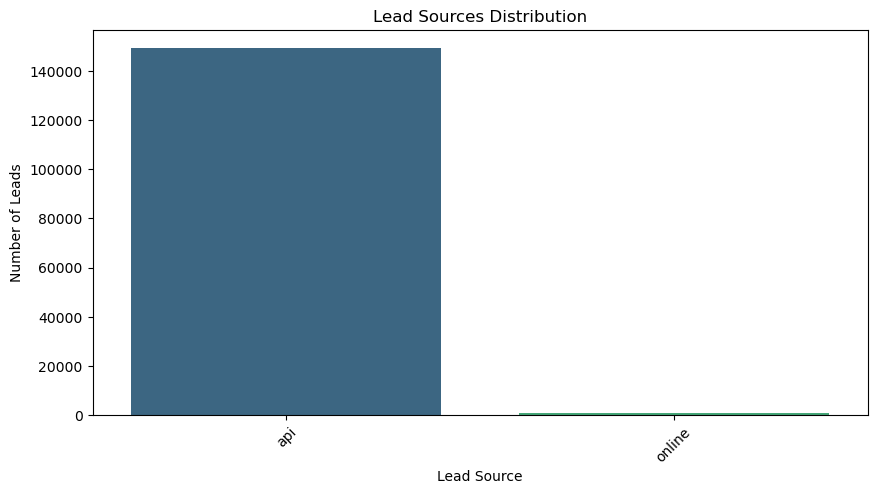

In [3]:
# 1️ Lead Source Analysis
if 'lead_origin' in df.columns:
    lead_source_counts = df['lead_origin'].value_counts()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=lead_source_counts.index, y=lead_source_counts.values, palette='viridis')
    plt.xticks(rotation=45)
    plt.title('Lead Sources Distribution')
    plt.xlabel('Lead Source')
    plt.ylabel('Number of Leads')
    plt.show()

In [4]:
# 2️ Program Performance Analysis
if 'course' in df.columns and 'enrolment_status' in df.columns:
    program_performance = df.groupby('course')['enrolment_status'].value_counts(normalize=True).unstack().fillna(0)
    print("\nProgram Conversion Rates:")
    print(program_performance.sort_values(by=program_performance.columns[0], ascending=False))


Program Conversion Rates:
enrolment_status                                          no       yes
course                                                                
ba english (hons)                                   1.000000  0.000000
ba - film and tv production                         1.000000  0.000000
m.tech.                                             1.000000  0.000000
ma (journalism and mass communication)              1.000000  0.000000
bachelor of fine arts (bfa)                         1.000000  0.000000
ma (psychology)                                     1.000000  0.000000
ba psychology (hons)                                1.000000  0.000000
ba economics (hons)                                 1.000000  0.000000
m.com - (forensic accounting and corporate frau...  1.000000  0.000000
ba digital economics (hons)                         1.000000  0.000000
ba (liberal studies) (hons)                         1.000000  0.000000
ba (journalism and mass communication)            

In [5]:
# 3️ Geographic Analysis
if 'state' in df.columns and 'enrolment_status' in df.columns:
    state_performance = df.groupby('state')['enrolment_status'].value_counts(normalize=True).unstack().fillna(0)
    print("\nTop Performing States:")
    print(state_performance.sort_values(by=state_performance.columns[0], ascending=False).head(10))


Top Performing States:
enrolment_status      no  yes
state                        
andaman and nicobar  1.0  0.0
haryana              1.0  0.0
uttarakhand          1.0  0.0
tripura              1.0  0.0
state not available  1.0  0.0
sikkim               1.0  0.0
punjab               1.0  0.0
puducherry           1.0  0.0
mizoram              1.0  0.0
meghalaya            1.0  0.0


D:\Program Files\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Program Files\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


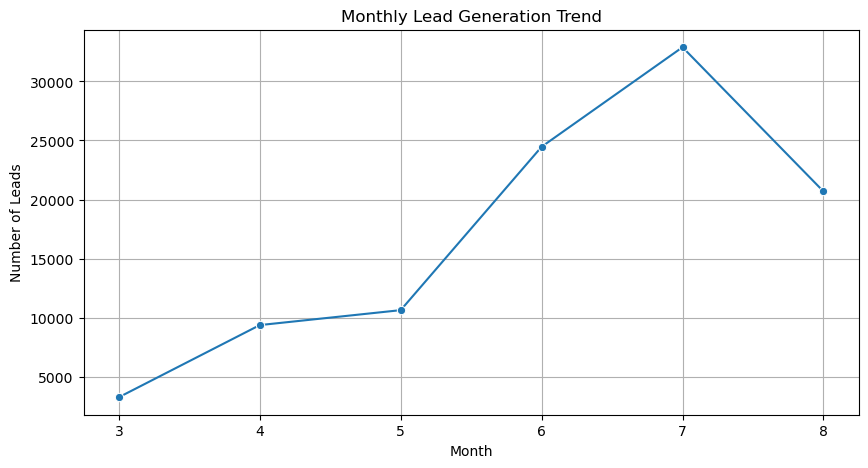

In [6]:
# 4️ Marketing Campaign Analysis
if 'instance_date' in df.columns:
    df['month'] = df['instance_date'].dt.month
    monthly_leads = df.groupby('month').size()
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=monthly_leads.index, y=monthly_leads.values, marker='o')
    plt.title('Monthly Lead Generation Trend')
    plt.xlabel('Month')
    plt.ylabel('Number of Leads')
    plt.grid()
    plt.show()

In [7]:
# 5️ Admissions Funnel Drop-off Analysis
if 'lead_stage' in df.columns and 'enrolment_status' in df.columns:
    lead_funnel = df.groupby('lead_stage')['enrolment_status'].value_counts(normalize=True).unstack().fillna(0)
    print("\nAdmissions Funnel Drop-offs:")
    print(lead_funnel.sort_values(by=lead_funnel.columns[0], ascending=False))


Admissions Funnel Drop-offs:
enrolment_status             no       yes
lead_stage                               
cold                   1.000000  0.000000
hot                    1.000000  0.000000
invalid                1.000000  0.000000
no response            1.000000  0.000000
not eligible           1.000000  0.000000
not interested         1.000000  0.000000
reject                 1.000000  0.000000
selected               1.000000  0.000000
untouched              1.000000  0.000000
warm                   1.000000  0.000000
application submitted  0.615509  0.384491


C:\Users\ghans\AppData\Local\Temp\ipykernel_17596\3844787210.py:15: UserWarning: Parsing dates in %m-%d-%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
C:\Users\ghans\AppData\Local\Temp\ipykernel_17596\3844787210.py:15: UserWarning: Parsing dates in %m-%d-%Y %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)


<Figure size 1200x800 with 0 Axes>

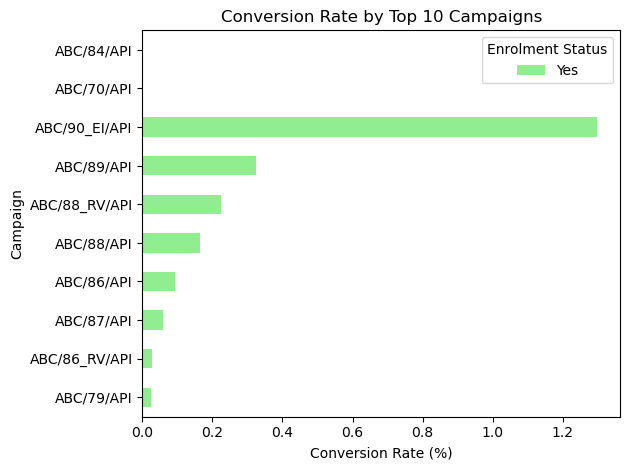

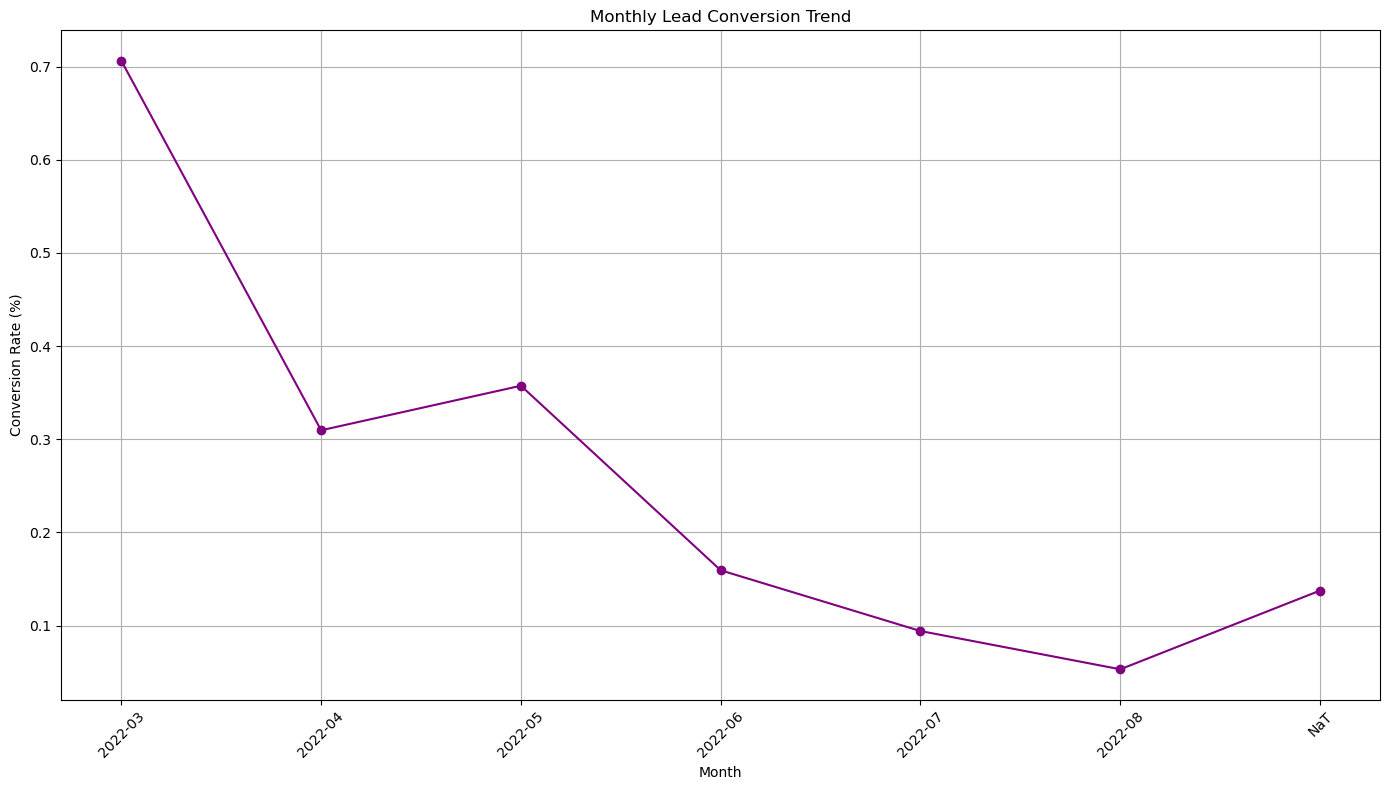

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots display inline in Jupyter Notebook
%matplotlib inline

# Load the dataset
file_path = "DUMP_27 Feb - Raw Data.csv"
df = pd.read_csv(file_path)

# Convert date columns to datetime format
date_columns = ["Instance Date", "Instance Date Upd", "Last Lead Activity Date", "Last Activity Date"]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
    
#  6: Conversion Rate by Top 10 Campaigns
plt.figure(figsize=(12, 8))
top_campaigns = df['Campaign'].value_counts().head(10).index
campaign_conversion = df[df['Campaign'].isin(top_campaigns)]\
    .groupby("Campaign")["Enrolment Status"].value_counts(normalize=True).unstack() * 100
campaign_conversion = campaign_conversion.sort_values(by='Yes', ascending=True)
if 'Yes' in campaign_conversion.columns:
    campaign_conversion[['Yes']].plot(kind='barh', color='lightgreen')
    plt.title('Conversion Rate by Top 10 Campaigns')
    plt.xlabel('Conversion Rate (%)')
    plt.ylabel('Campaign')
    plt.tight_layout()
    plt.show()


#  7: Monthly Conversion Trend
plt.figure(figsize=(14, 8))
# Create a new column for the inquiry month
df['Inquiry Month'] = df["Instance Date"].dt.to_period("M").astype(str)
monthly_conversion = df.groupby("Inquiry Month")["Enrolment Status"].value_counts(normalize=True).unstack() * 100
if 'Yes' in monthly_conversion.columns:
    monthly_conversion['Yes'].plot(marker='o', color='purple')
    plt.title('Monthly Lead Conversion Trend')
    plt.xlabel('Month')
    plt.ylabel('Conversion Rate (%)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()